In [1]:
import pandas as pd

df = pd.read_csv("../../data/df_with_cat.csv")
df = df.drop(columns=["Unnamed: 0", "model_response_timestamp", "number"])
display(df.head())

,latitude,longitude,query,org_found,org_name,org_type,org_rating,org_lat,org_lon,name,time,category
0,37.874904,32.492129,Konumumdan en yakın rotayı çıkar,True,Konya Büyükşehir Belediye Stadyumu,Stadyum,4.9,37.946209,32.488097,Konya,2026-02-21 15:09:14,Sports and active recreation
1,41.011219,28.978176,Takı Dünyası Nerdedir?,True,Takı Dünyası,Kozmetik ve parfümeri mağazaları,NaN,41.009805,28.694718,İstanbul,2026-03-01 21:32:04,"Beauty, personal care and wellness"
2,41.011219,28.978176,Şuan bulunduğum konumdan bursa görükle ye gide...,False,NaN,NaN,NaN,NaN,NaN,İstanbul,2026-02-14 10:43:32,Other and unspecified
3,37.062688,37.379510,Milano da gezilecek yerler bana söyler misin?,False,NaN,NaN,NaN,NaN,NaN,Gaziantep,2026-02-22 06:41:22,Other and unspecified
4,37.181190,33.222247,karaman adana arası kaç km ve tır ne yakar,True,Karaman,Locality,NaN,37.181193,33.222241,Karaman,2026-02-23 08:42:57,"Landmarks, addresses and geography"


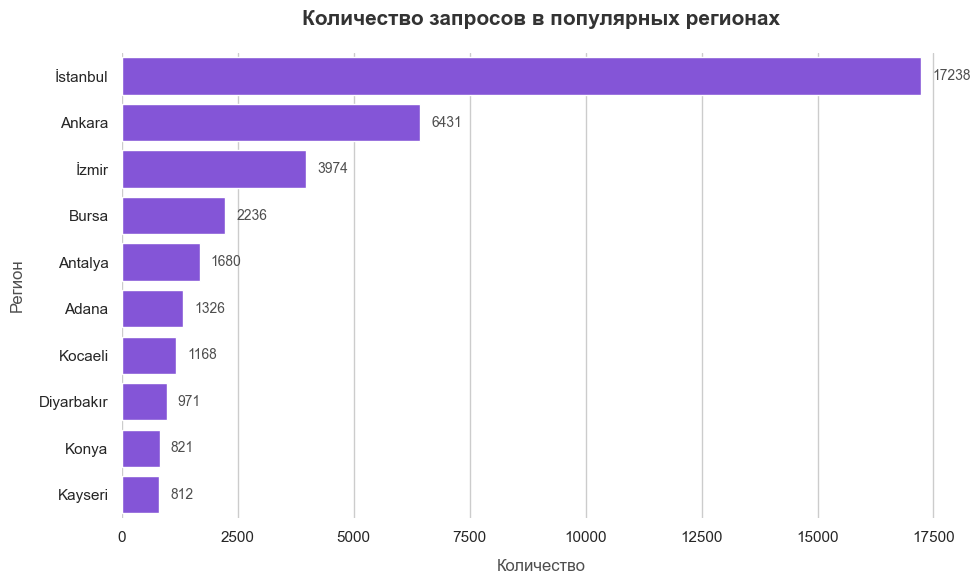

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

grouped_df = (
    df.groupby("name")["query"].count().reset_index(name="count")
)

grouped_df = (
    grouped_df[grouped_df["count"] >= 750]
    .sort_values(by="count", ascending=False)
)

plt.figure(figsize=(10, 6))
lilac_color = "#7e40ec" 

ax = sns.barplot(
    data=grouped_df,
    x="count",
    y="name",
    color=lilac_color
)

ax.bar_label(ax.containers[0], padding=8, fontsize=10, color="#4F4F4F")

plt.title("Количество запросов в популярных регионах", fontsize=15, fontweight="bold", pad=20, color="#333333")
plt.xlabel("Количество", fontsize=12, labelpad=10, color="#4F4F4F")
plt.ylabel("Регион", fontsize=12, labelpad=10, color="#4F4F4F")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('regions.png', dpi=300)
plt.show()

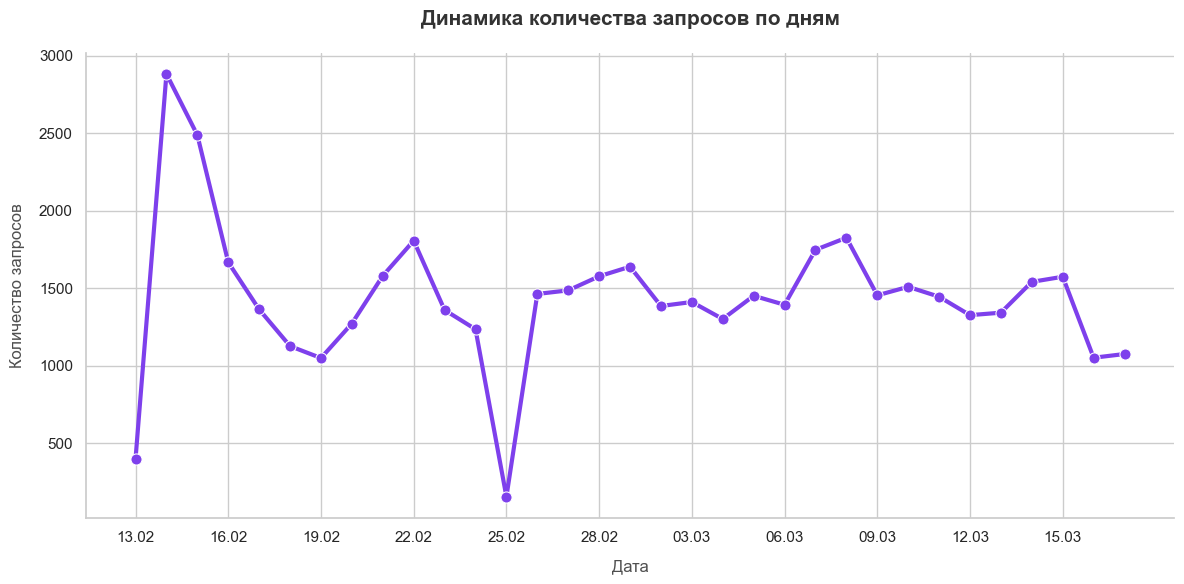

In [9]:
df["time"] = pd.to_datetime(df["time"])
df["date"] = df["time"].dt.date
df["day_name"] = df["time"].dt.strftime("%d.%m")

grouped_df = (
    df.groupby(["date", "day_name"])["query"].count().reset_index(name="count")
)
grouped_df = grouped_df.sort_values(by="date")

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

purple = "#7e40ec"

ax = sns.lineplot(
    data=grouped_df, 
    x="day_name", 
    y="count", 
    color=purple, 
    linewidth=3,
    marker="o",   
    markersize=8 
)

ax.set_xticks(range(0, len(grouped_df), 3))
ax.set_xticklabels(grouped_df["day_name"].iloc[::3])

plt.title("Динамика количества запросов по дням", fontsize=15, fontweight="bold", pad=20, color="#333333")
plt.xlabel("Дата", fontsize=12, labelpad=10, color="#4F4F4F")
plt.ylabel("Количество запросов", fontsize=12, labelpad=10, color="#4F4F4F")

sns.despine(left=False, bottom=False)

plt.tight_layout()
plt.savefig('days_trend.png', dpi=300)
plt.show()

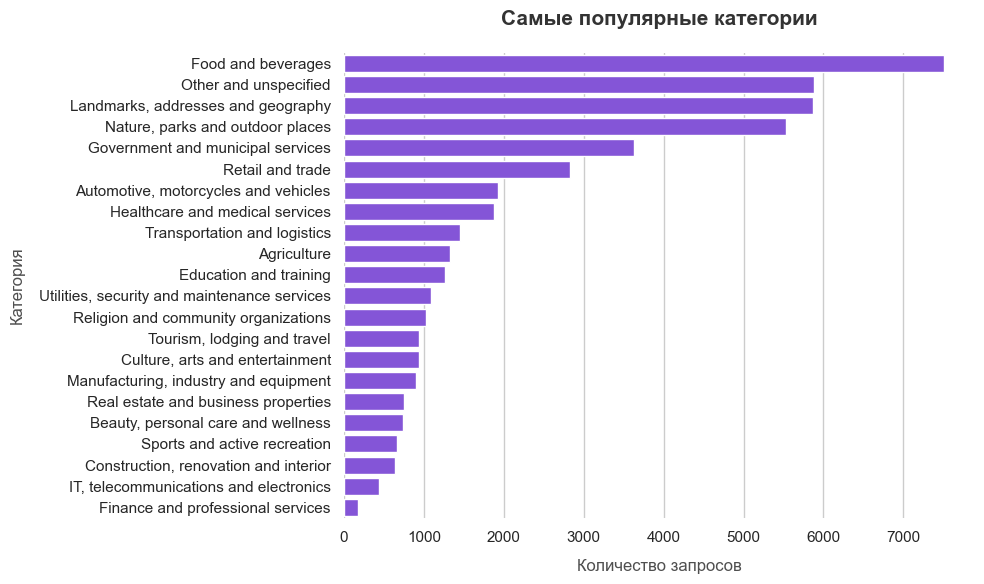

In [17]:
grouped_df = (
    df.groupby("category")["query"].count().reset_index(name="count")
)
grouped_df = grouped_df.sort_values(by="count", ascending=False)

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

soft_coral = "#7e40ec"

ax = sns.barplot(
    data=grouped_df,
    x="count",
    y="category",
    color=soft_coral
)

plt.title("Самые популярные категории", fontsize=15, fontweight="bold", pad=20, color="#333333")
plt.xlabel("Количество запросов", fontsize=12, labelpad=10, color="#4F4F4F")
plt.ylabel("Категория", fontsize=12, labelpad=10, color="#4F4F4F")

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('categories.png', dpi=300)
plt.show()

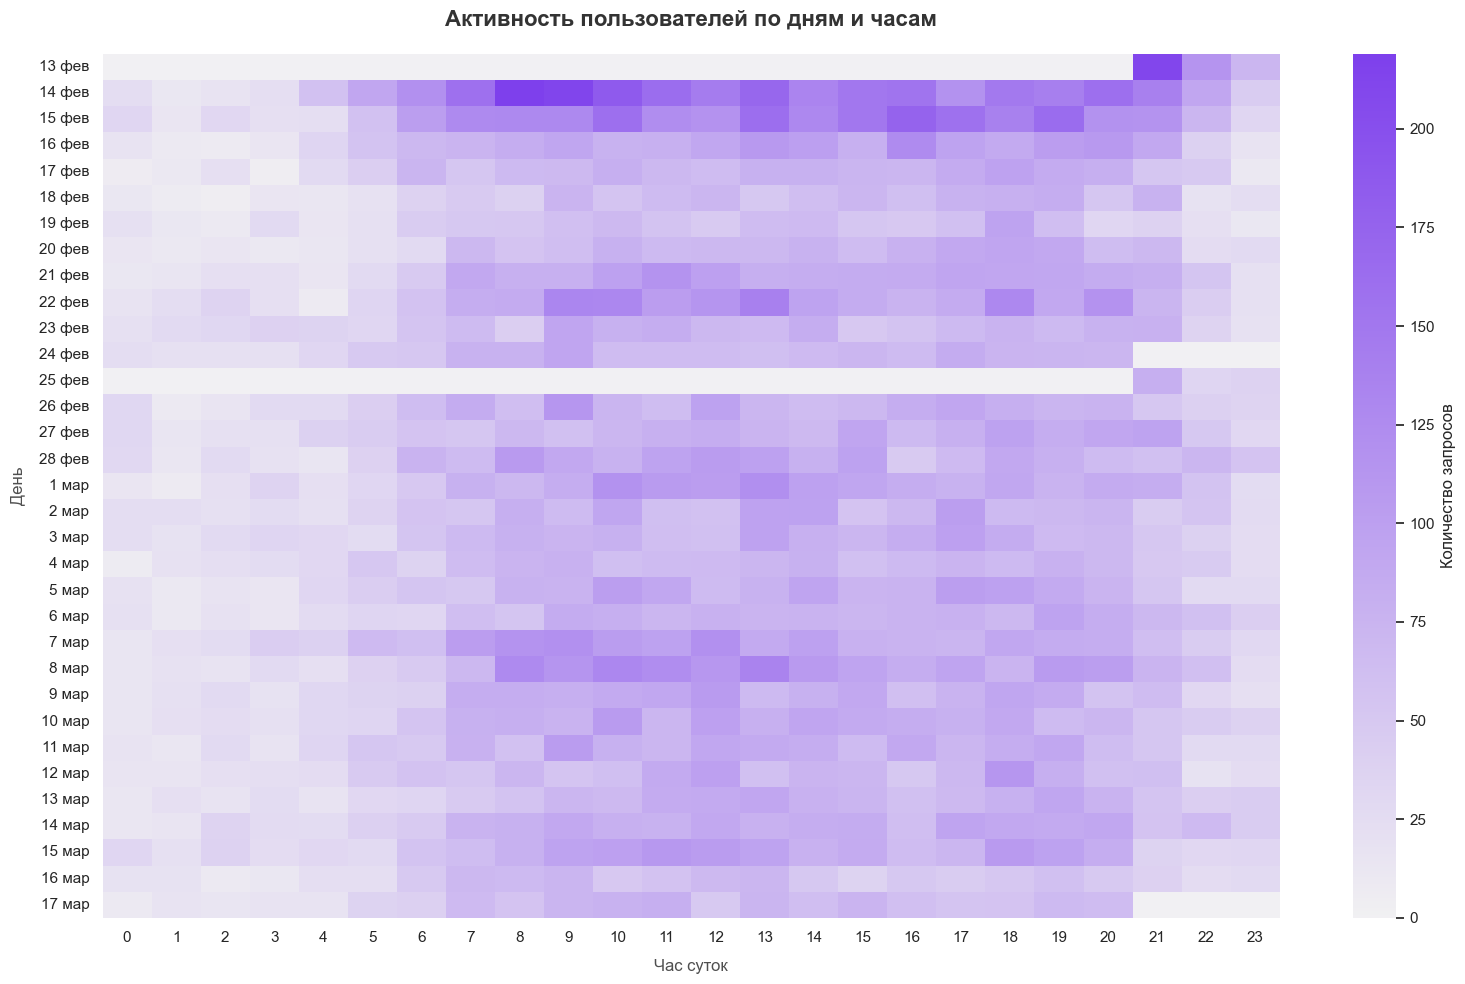

In [18]:
df["time"] = pd.to_datetime(df["time"])

ru_months = {
    1: "янв", 2: "фев", 3: "мар", 4: "апр", 5: "май", 6: "июн",
    7: "июл", 8: "авг", 9: "сен", 10: "окт", 11: "ноя", 12: "дек"
}

df["day_name"] = df["time"].dt.day.astype(str) + " " + df["time"].dt.month.map(ru_months)
df["hour"] = df["time"].dt.hour

pivot_df = df.pivot_table(
    index="day_name", 
    columns="hour", 
    values="query", 
    aggfunc="count", 
    fill_value=0
)

df_sorted_days = df.sort_values("time")["day_name"].unique()
pivot_df = pivot_df.reindex(df_sorted_days)

plt.figure(figsize=(16, 10))
sns.set_theme(style="white")

custom_cmap = sns.light_palette("#7e40ec", as_cmap=True)

sns.heatmap(
    pivot_df, 
    cmap=custom_cmap, 
    annot=False, 
    cbar_kws={"label": "Количество запросов"}
)

plt.title("Активность пользователей по дням и часам", fontsize=16, fontweight="bold", pad=20, color="#333333")
plt.xlabel("Час суток", fontsize=12, labelpad=10, color="#4F4F4F")
plt.ylabel("День", fontsize=12, labelpad=10, color="#4F4F4F")

plt.tight_layout()
plt.savefig('activity_heatmap.png', dpi=300)
plt.show()

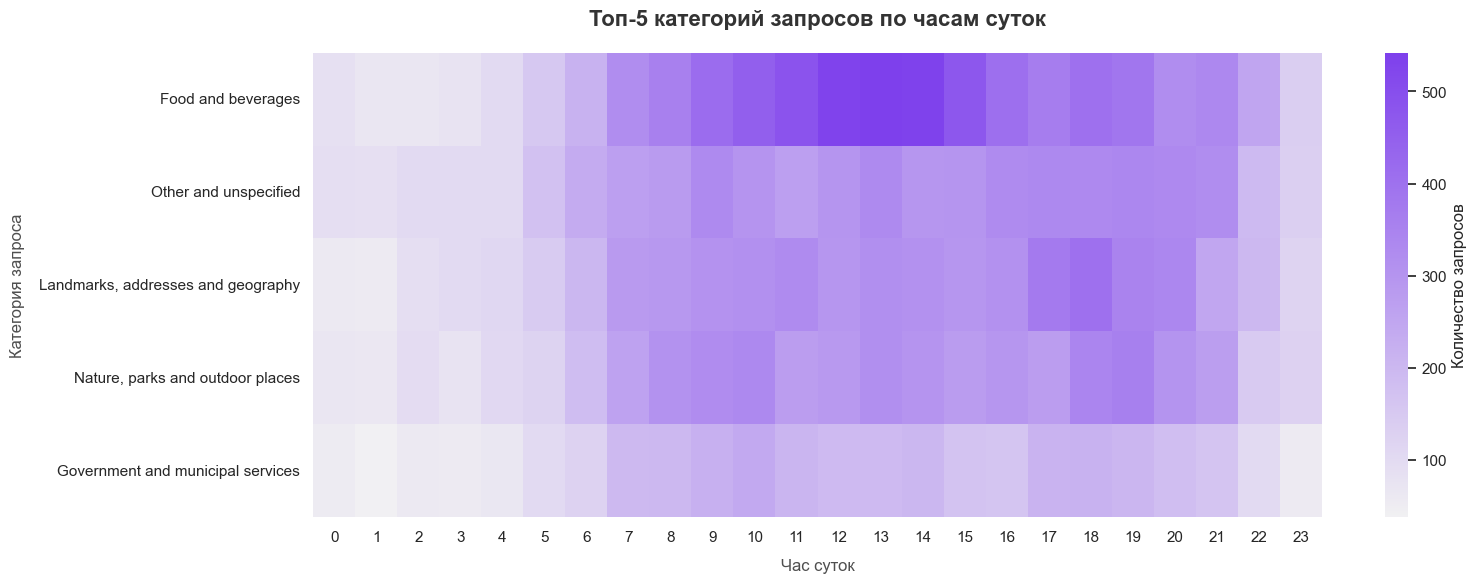

In [19]:
df["time"] = pd.to_datetime(df["time"])
df["hour"] = df["time"].dt.hour

pivot_df = df.pivot_table(
    index="category", 
    columns="hour", 
    values="query", 
    aggfunc="count", 
    fill_value=0
)

top_5_categories = df["category"].value_counts().head(5).index
pivot_df = pivot_df.reindex(top_5_categories)

plt.figure(figsize=(16, 6))
sns.set_theme(style="white")

custom_cmap = sns.light_palette("#7e40ec", as_cmap=True)

sns.heatmap(
    pivot_df, 
    cmap=custom_cmap, 
    annot=False, 
    fmt="d",
    cbar_kws={"label": "Количество запросов"}
)

plt.title("Топ-5 категорий запросов по часам суток", fontsize=16, fontweight="bold", pad=20, color="#333333")
plt.xlabel("Час суток", fontsize=12, labelpad=10, color="#4F4F4F")
plt.ylabel("Категория запроса", fontsize=12, labelpad=10, color="#4F4F4F")

plt.tight_layout()
plt.savefig('heatmap.png', dpi=300)
plt.show()